# Transforming Long Videos into Social Media-Optimized Shorts Using Python

# Problem Statement:
Content creators need to repurpose their landscape (16:9) video content into vertical (9:16) format
for social media platforms like Instagram Reels, TikTok, and YouTube Shorts. The transformation
should maintain video quality while adapting to platform-specific requirements. Video editors often spend
significant time identifying interesting clips, editing, and cropping content. This limits the number of shorts
they can produce, impacting content reach and engagement.

# Solution:

### Social Media Content Repurposing
Platforms like Instagram Reels, TikTok, and YouTube Shorts prefer short, vertically-oriented videos. By converting long 16:9 videos into short, 9:16 clips, you can create engaging, shareable content that reaches a broader audience.

### Purpose and Benefits
1. **Increased Engagement**: Short, mobile-friendly videos hold viewers' attention.
2. **Optimized Viewing**: 9:16 format suits vertical video platforms.
3. **Key Point Focus**: Short clips highlight key information for easier consumption.
4. **Enhanced SEO**: Bite-sized clips rank better and are more accessible.

### Workflow Using Python (OpenCV, MoviePy, FFmpeg)
1. **Extract Key Segments**: Identify important parts of the video for clipping.
2. **Resize and Crop**: Adjust 16:9 videos to the 9:16 format.
3. **Enhance** (Optional): Add captions or overlays for better engagement.
4. **Export**: Save in formats optimized for social platforms.

This approach helps you maximize content reach and impact across multiple social media platforms.

## Leveraging Gemini's Long Context for Efficiency and Quality
By using Gemini's long context capabilities, the project can process and analyze extended video files more effectively. This enables:
- **Efficient Clipping and Highlighting**: Gemini can retain a broad context of the entire video, making it easier to identify key scenes, themes, or highlights, which saves time for video editors.
- **Consistent Storyline Recognition**: Long context allows the tool to maintain the narrative flow across extended durations, avoiding fragmented clips and ensuring a cohesive storyline in each short.
- **Scalability**: Editors can handle more videos within limited timeframes, increasing the number of high-quality shorts produced and boosting audiee engagement across platforms.

e engagement across platforms.



In [ ]:
from IPython.display import IFrame

# Replace the link with the one you want to display
video_url = "https://www.youtube.com/embed/TUMdFXASNlU"
IFrame(src=video_url, width="560", height="315")

# install the requirments

In [ ]:
!pip install -q \
opencv-python==4.7.0.72 \
moviepy \
tqdm==4.65.0 \
numpy==1.24.2 \
pytube==15.0.0 \
google-generativeai==0.7.0 \
python-dotenv==1.0.1 \
pydantic==2.7.4 \
youtube-transcript-api==0.6.2 \
yt-dlp==2024.8.6 \
pydub==0.25.1 \
ultralytics==8.2.42 \
scenedetect==0.6.4 \
streamlit==1.36.0 \
langchain==0.2.10 \
langchain-google-genai==1.0.7 \
gradio==4.41.0 \
srt

!pip3 install ffmpeg --upgrade
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip3 install --upgrade pydantic

# ⚠️ ATTENTION After running the cell below, your kernel will restart

In [ ]:
# Raise a SystemExit to trigger a kernel restart
import os
os._exit(00)

## Running all the below cell from the notebook
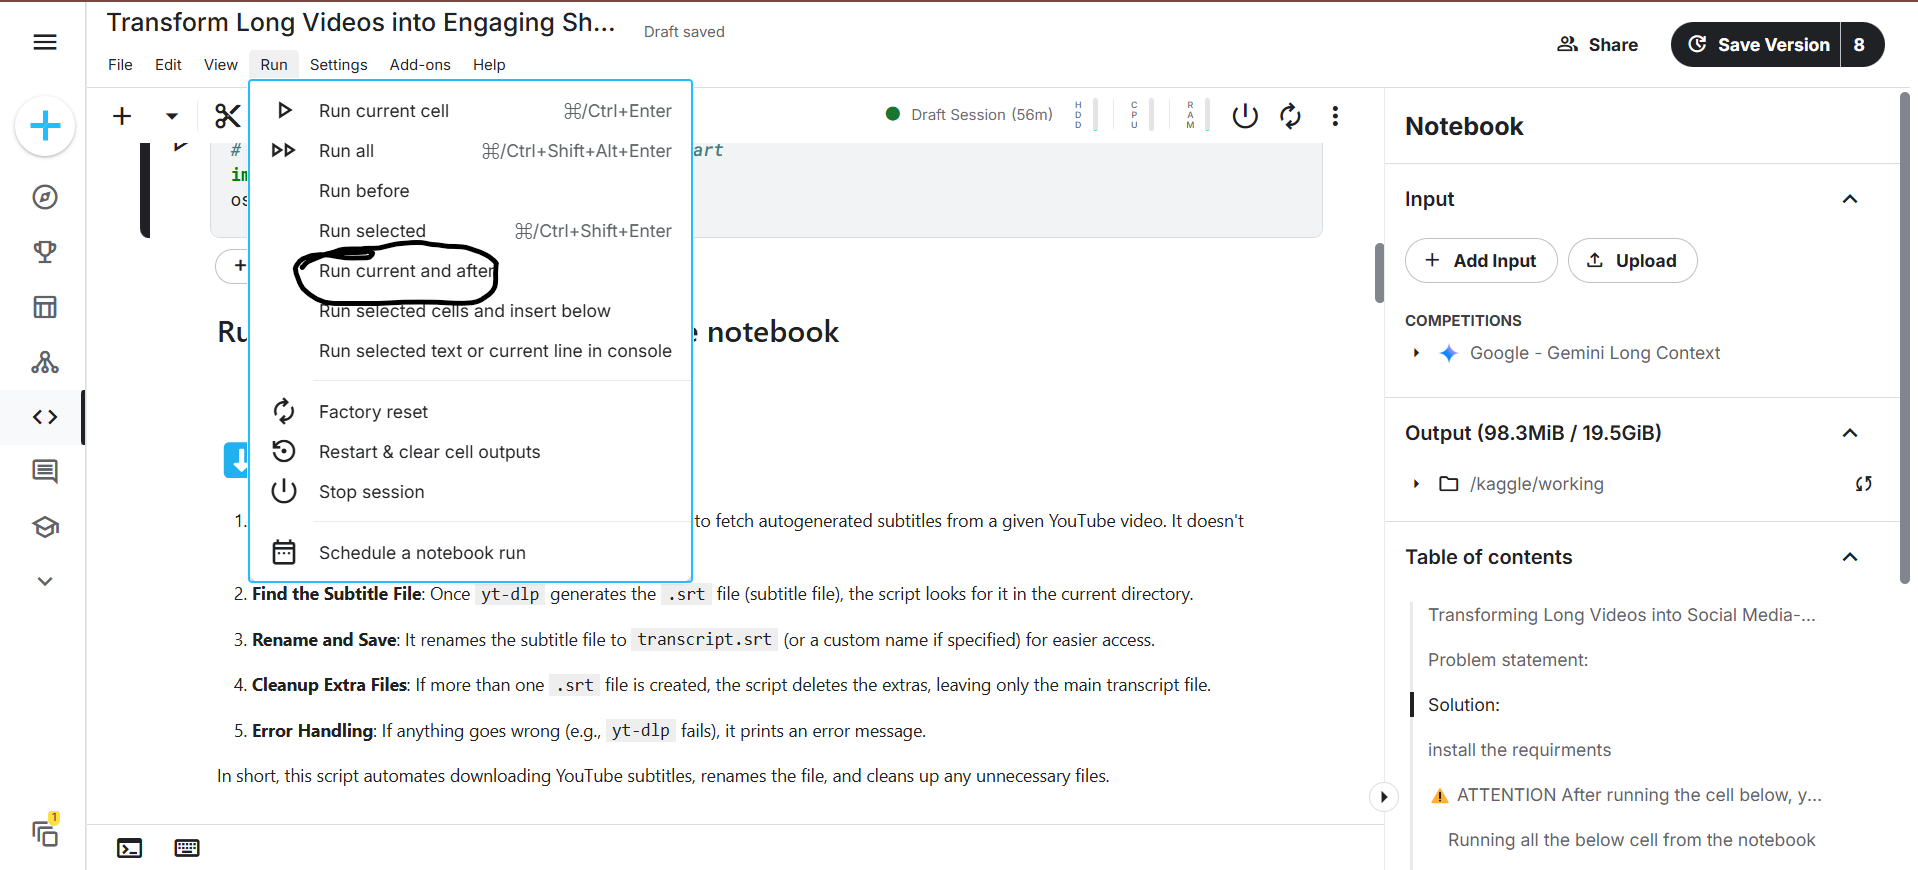

# ⬇️ Downloading Transcript
1. **Run `yt-dlp` to Get Subtitles**: The script uses `yt-dlp` to fetch autogenerated subtitles from a given YouTube video. It doesn't download the video itself, just the subtitles.

2. **Find the Subtitle File**: Once `yt-dlp` generates the `.srt` file (subtitle file), the script looks for it in the current directory.

3. **Rename and Save**: It renames the subtitle file to `transcript.srt` (or a custom name if specified) for easier access.

4. **Cleanup Extra Files**: If more than one `.srt` file is created, the script deletes the extras, leaving only the main transcript file.

5. **Error Handling**: If anything goes wrong (e.g., `yt-dlp` fails), it prints an error message.

In short, this script automates downloading YouTube subtitles, renames the file, and cleans up any unnecessary files.

In [ ]:
import subprocess
import os
import glob

def fetch_and_save_transcript(video_url, output_file='transcript.srt'):
    try:
        # Run yt-dlp command
        subprocess.run([
            'yt-dlp',
            '--write-auto-sub',
            '--convert-subs=srt',
            '--skip-download',
            video_url
        ], check=True)

        # Find the generated .srt file
        srt_files = glob.glob('*.srt')
        if not srt_files:
            print("Error: No .srt file was generated.")
            return

        # Rename the first .srt file found to transcript.srt
        os.rename(srt_files[0], output_file)
        print(f"Transcript saved as {output_file}")

        # Clean up any other .srt files if multiple were generated
        for file in srt_files[1:]:
            os.remove(file)

    except subprocess.CalledProcessError as e:
        print(f"Error running yt-dlp: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage
# if __name__ == "__main__":
#     video_url = input("Enter the YouTube video URL: ")
#     fetch_and_save_transcript(video_url)


# 📃 Transcript Best Parts Extractor using Google Generative AI

This code implements a `TranscriptBestPartsExtractor` class that uses the Google Generative AI (Gemini) language model to identify the most important and valuable parts of a transcript.

The main functionality of this code is:

1. **Configuring the Gemini model**: The class initializes the Gemini language model with a specified API key and configuration.

2. **Extracting best parts from a transcript**: The `extract_best_parts()` method takes a transcript file (in JSON format) and a desired number of segments to extract. It then uses the Gemini model to analyze the transcript and select the most important parts based on a custom prompt.

3. **Validating and saving the results**: The method ensures that the extracted segments have the required fields and adhere to the specified format. It then saves the results to a new JSON file named "best_segments.json".

4. **Running the extraction process**: The `gemini_insights()` function is the entry point that initializes the `TranscriptBestPartsExtractor` class with the necessary Google API key and calls the `extract_best_parts()` method.

To use this code, you'll need to have the following:

1. A Kaggle notebook with the necessary dependencies installed (e.g., `google.generativeai`, `langchain_google_genai`, `langchain.prompts`, `json`, `kaggle_secrets`).
2. A Google API key that provides access to the Generative AI (Gemini) model.
3. A transcript file in JSON format located in the `/kaggle/working/` directory.

After running the code, the most important parts of the transcript will be saved in the "best_segments.json" file, which can be further analyzed or used for other purposes.

**Note:** This code assumes that you have the necessary Kaggle and Google API credentials set up correctly. If you encounter any issues, please ensure that you have the correct API key and that your Kaggle environment is configured properly.s configured properly.

In [ ]:
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
import json
# from dotenv import load_dotenv
import os
# load_dotenv()
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

class TranscriptBestPartsExtractor:
    def __init__(self, google_api_key):
        # Configure Gemini
        genai.configure(api_key=google_api_key)
        
        # Initialize Gemini model for chat
        self.llm = ChatGoogleGenerativeAI(
            model="gemini-1.5-flash-002",
            temperature=0.7,
            google_api_key=google_api_key
        )

    def extract_best_parts(self, transcript_file, topic, num_segments=3):
        """Extract the most important segments using Gemini from transcript.json"""
        
        # Read the transcript file
        try:
            with open(transcript_file, 'r', encoding='utf-8') as f:
                json_data = json.load(f)
        except Exception as e:
            raise ValueError(f"Error reading transcript file: {str(e)}")

        prompt_template = """You are an AI trained to identify the most important and valuable parts of a transcript.
        
        Analyze these transcript segments and select exactly {num_segments} most important parts that provide the most value about:
        {topic}
        Transcript segments:
        {segments}
        
        Requirements:
        1. Return ONLY a JSON array with the {num_segments} best segments
        2. Each object must have exactly these keys: "start_time", "end_time", "description", "duration"
        3. Keep the exact original timing information and text
        4. Do not modify or summarize the text content
        5. Include only complete thoughts/segments
        6. Format as a valid JSON array
        7. Do not add any extra text or explanations
        8. the clips should be min 50 seconds in duration
        
        Return only the JSON array, nothing else."""
        
        prompt = ChatPromptTemplate.from_template(prompt_template)
        
        # Create JSON string of segments
        segments_str = json.dumps(json_data, indent=2)
        
        # Create messages
        messages = prompt.format_messages(
            segments=segments_str,
            topic=topic,
            num_segments=num_segments
        )
        
        # Get response from Gemini
        response = self.llm.invoke(messages)
        
        # Extract JSON from response
        try:
            # Find the JSON array in the response
            response_text = response.content
            start_idx = response_text.find('[')
            end_idx = response_text.rfind(']') + 1
            
            if start_idx == -1 or end_idx == 0:
                raise ValueError("No JSON array found in response")
                
            json_str = response_text[start_idx:end_idx]
            best_segments = json.loads(json_str)
            
            # Validate each segment
            for segment in best_segments:
                # Check required fields
                required_fields = ["start_time", "end_time", "description", "duration"]
                if not all(field in segment for field in required_fields):
                    raise ValueError("Missing required fields in segment")
                
                # Validate types
                if not isinstance(segment["start_time"], (int, float)):
                    raise ValueError("start_time must be a number")
                if not isinstance(segment["end_time"], (int, float)):
                    raise ValueError("end_time must be a number")
                if not isinstance(segment["duration"], (int, float)):
                    raise ValueError("duration must be a number")
                if not isinstance(segment["description"], str):
                    raise ValueError("description must be a string")
                    
            # Save the results to a new file
            output_file = "best_segments.json"
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(best_segments, f, indent=2, ensure_ascii=False)
                
            print(f"Best segments saved to {output_file}")
            return best_segments
            
        except json.JSONDecodeError:
            raise ValueError("Failed to parse Gemini response as JSON")

def gemini_insights():
    # Your Google API key
    GOOGLE_API_KEY = secret_value_0 = user_secrets.get_secret("GEMINI_API_KEY")
    # GOOGLE_API_KEY = secret_value_0 = os.getenv("GEMINI_API_KEY")
    
    # Initialize extractor
    extractor = TranscriptBestPartsExtractor(GOOGLE_API_KEY)
    
    # Prompt user for the topic
    topic = input("Enter the topic you want to extract the most important segments about: ")
    
    # Process transcript and get best parts
    best_segments = extractor.extract_best_parts("/kaggle/working/transcript.json", topic, num_segments=3)
    
    # Print results
    print("\nBest transcript segments:")
    print(json.dumps(best_segments, indent=2))

# if __name__ == "__main__":
    # gemini_insights()

# 📽️ video processing
1. **Setup and File Creation**: The function `trim_video` takes three inputs: the path to the input video file, a JSON file specifying video segments (start and end times), and an output folder for storing the trimmed clips. It creates the output folder if it doesn't already exist.

2. **Load Video Segments**: It reads the JSON file (e.g., `best_segments.json`) which contains information on the start and end times of the segments to be trimmed.

3. **Trim and Save Clips**: For each segment in the JSON file:
   - It trims the video between the specified start and end times.
   - Saves each segment as a new video file in the output folder with a unique name (e.g., `clip_1.mp4`).

4. **Close the Video**: After processing, it closes the main video file to release resources.

This script is useful for trimming specific parts of a video automatically based on pre-defined segments and saving them as separate files.

In [ ]:
import json
import os
from moviepy.video.io.VideoFileClip import VideoFileClip

def trim_video(input_file, parts_file, output_folder):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Load the parts from the JSON file
    with open(parts_file, 'r') as f:
        parts = json.load(f)
    
    # Load the input video
    video = VideoFileClip(input_file)
    
    # Process each part and save the clips
    for index, part in enumerate(parts):
        start_time = part['start_time']
        end_time = part['end_time']
        duration = end_time - start_time
        
        # Trim the video for the given start and end times
        clip = video.subclip(start_time, end_time)
        
        # Generate the output file name
        output_file = os.path.join(output_folder, f'clip_{index + 1}.mp4')
        
        # Write the clip to a file
        clip.write_videofile(output_file, codec='libx264', audio_codec='aac')
        
        print(f'Saved {output_file}')
    
    # Close the video file
    video.close()


# if __name__=='__main__':
# # # Define file paths
#     input_video = '/kaggle/working/input.mp4'
#     parts_json = '/kaggle/working/best_segments.json'
#     output_clips_folder = '/kaggle/working/Clips'

#     # Call the function
#     trim_video(input_video, parts_json, output_clips_folder)


1. **Set Up and Load Model**:
   - Defines folder paths for video processing and configuration constants.
   - Loads a YOLOv8 model, selecting the GPU if available for face detection.

2. **Face Detection**:
   - Detects faces in video frames using the YOLOv8 model. Only faces with high confidence (above the set threshold) are kept for cropping.

3. **Calculate Crop Area**:
   - Determines the cropping region for each frame, keeping faces centered and using a 9:16 aspect ratio for portrait-style output.

4. **Process Video**:
   - Iterates over frames, detects faces, and crops based on face positions.
   - Outputs the processed video to maintain the 9:16 ratio and optionally shows a split-screen if there are two faces.

5. **Scene Detection**:
   - Uses `pySceneDetect` to split the video into scenes based on content change, saving each scene separately.

6. **Compile Videos**:
   - Compiles all processed scene clips into a final video.

7. **Check and Trim Extra Frames**:
   - Checks for extra frames by comparing the original and processed scene durations.
   - Trims processed scenes if they exceed the original duration.

8. **Process All Videos**:
   - This main function applies the above steps to each video, creating necessary folders, processing each video
   -  and compiling the output.

In summary, this script automates face detection, scene detection, cropping, and merging of videos for portrait-style content, making it suitable for generating social media-friendly video formats.

In [ ]:
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm
from moviepy.editor import VideoFileClip, concatenate_videoclips
from scenedetect import detect, ContentDetector, split_video_ffmpeg
from scenedetect.video_manager import VideoManager
from scenedetect.scene_manager import SceneManager
from scenedetect.stats_manager import StatsManager
from ultralytics import YOLO
import torch
# Constants
CLIPS_FOLDER = '/kaggle/working/Clips'
OUTPUT_FOLDER = '/kaggle/working/output'
TEMP_VIDEOS_FOLDER = '/kaggle/working/temp_videos'
VIDEOS_FOLDER = '/kaggle/working/videos'
DETECTION_FREQUENCY = 7
SMOOTHING_FACTOR = 0.9
STABILITY = 0.9
CONFIDENCE_THRESHOLD = 0.7  # Add this line for the confidence threshold

# Load the YOLOv8s model you can use yolov8n.pt,yolov8s.pt,yolov8m.pt,yolov8x.pt you can download the model from here: (https://github.com/ultralytics/ultralytics)
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = YOLO('yolov8m.pt').to(device)
# model.torch_device = 'cpu'
# this function detects the faces and uses the Yolov8 small model.
def detect_faces(frame, model):
    results = model(frame,verbose=False)
    faces = []
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf, cls = box.conf.item(), int(box.cls)
            if cls == 0 and conf > CONFIDENCE_THRESHOLD:  # Class 0 is 'person' in COCO dataset
                faces.append((int(x1), int(y1), int(x2), int(y2)))
    return faces

# here we calculate the crop region to crop the video in 9:16 ratio and too use a split screen if there is two person in the video.
def calculate_crop_area(frame_shape, faces, current_crop, last_good_crop, stability):
    height, width, _ = frame_shape
    new_width = int(height * 9 / 16)

    if not faces:
        return last_good_crop if last_good_crop else (0, new_width)

    min_x = max(0, min(face[0] for face in faces))
    max_x = min(width, max(face[2] for face in faces))
    center_x = (min_x + max_x) // 2
    target_left = max(0, min(width - new_width, center_x - new_width // 2))

    if current_crop:
        crop_left, _ = current_crop
        left = int(stability * crop_left + (1 - stability) * target_left)
    else:
        left = target_left

    return left, min(width, left + new_width)

def process_video(input_video, output_video, model):
    video = VideoFileClip(input_video)
    fps = video.fps
    height = video.size[1]
    width = video.size[0]
    total_frames = int(video.duration * fps)

    temp_output_file_path = 'temp_output.mp4'
    out = cv2.VideoWriter(temp_output_file_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (int(height * 9 / 16), height))

    current_crop = None
    last_good_crop = None
    face_tracks = [[], []]
    two_faces_mode = False
    one_face_mode = False

    initial_positions = None
    face_movements = []
    avg_crop_region = None

    for i, frame in enumerate(tqdm(video.iter_frames(), desc=f"Processing {input_video}", total=total_frames)):
        if i % DETECTION_FREQUENCY == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            faces = detect_faces(frame_rgb, model)
            
            if len(faces) >= 2:
                two_faces_mode = True
                one_face_mode = False
                if initial_positions is None or len(initial_positions) < 2:
                    initial_positions = faces[:2]
                face_tracks[0].append(faces[0])
                face_tracks[1].append(faces[1])
            elif len(faces) == 1:
                two_faces_mode = False
                one_face_mode = True
                if initial_positions is None:
                    initial_positions = faces
                face_movements.append(faces[0])
            else:
                two_faces_mode = False
                one_face_mode = False

            if one_face_mode:
                left, right = calculate_crop_area(frame.shape, faces, current_crop, last_good_crop, stability=STABILITY)
                current_crop = (left, right)
                last_good_crop = current_crop
                
                if avg_crop_region is None:
                    avg_crop_region = current_crop
                else:
                    avg_crop_region = (
                        int(SMOOTHING_FACTOR * avg_crop_region[0] + (1 - SMOOTHING_FACTOR) * current_crop[0]),
                        int(SMOOTHING_FACTOR * avg_crop_region[1] + (1 - SMOOTHING_FACTOR) * current_crop[1])
                    )
            elif not two_faces_mode:
                if last_good_crop:
                    current_crop = last_good_crop
                else:
                    new_width = int(height * 9 / 16)
                    left = (width - new_width) // 2
                    current_crop = (left, left + new_width)

        if two_faces_mode and initial_positions and len(initial_positions) >= 2:
            face1 = initial_positions[0]
            face2 = initial_positions[1]
            
            crop1 = frame[face1[1]:face1[3], face1[0]:face1[2]]
            crop2 = frame[face2[1]:face2[3], face2[0]:face2[2]]
            
            crop1 = cv2.resize(crop1, (int(height * 9 / 32), int(height / 2)))
            crop2 = cv2.resize(crop2, (int(height * 9 / 32), int(height / 2)))
            
            stacked_frame = np.vstack((crop1, crop2))
            resized_frame = cv2.resize(stacked_frame, (int(height * 9 / 16), height))
        else:
            if one_face_mode and avg_crop_region:
                cropped_frame = frame[:, avg_crop_region[0]:avg_crop_region[1]]
            else:
                cropped_frame = frame[:, current_crop[0]:current_crop[1]]
            resized_frame = cv2.resize(cropped_frame, (int(height * 9 / 16), height))

        out.write(cv2.cvtColor(resized_frame, cv2.COLOR_RGB2BGR))

    out.release()

    processed_video = VideoFileClip(temp_output_file_path)
    if video.audio:
        audio = video.audio.set_duration(processed_video.duration)
        processed_video = processed_video.set_audio(audio)

    processed_video.write_videofile(output_video, codec='libx264', audio_codec='aac', bitrate='5000k')

    video.close()
    processed_video.close()
    os.remove(temp_output_file_path) 

# here we use the pyScenceDetect module to detect scenes from the video and then cut it and store it in the output folder.
def detect_and_save_scenes(video_path, output_folder, threshold=30.0):
    os.makedirs(output_folder, exist_ok=True)
    
    video_manager = VideoManager([video_path])
    stats_manager = StatsManager()
    scene_manager = SceneManager(stats_manager)
    
    scene_manager.add_detector(ContentDetector(threshold=threshold))
    
    cv2.setNumThreads(0)
    cv2.ocl.setUseOpenCL(False)
    
    video_manager.start()
    
    scene_manager.detect_scenes(frame_source=video_manager)
    
    scene_list = scene_manager.get_scene_list()
    
    split_video_ffmpeg(video_path, scene_list, output_folder,
                       show_progress=True, show_output=False)
    
    print(f"Scene detection complete. Scenes saved in {output_folder}")

# here it complies the video given by the cropped videos stored in the temp_videos and then adds all together.
def compile_videos(input_folder, output_folder):
    video_files = [f for f in os.listdir(input_folder) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    video_files.sort()
    
    clips = []
    for video_file in video_files:
        video_path = os.path.join(input_folder, video_file)
        clips.append(VideoFileClip(video_path))
    
    final_clip = concatenate_videoclips(clips, method="compose")
    
    os.makedirs(output_folder, exist_ok=True)
    
    existing_files = [f for f in os.listdir(output_folder) if f.startswith('video_') and f.endswith('.mp4')]
    existing_files.sort()
    
    if existing_files:
        last_file = existing_files[-1]
        next_number = int(last_file.split('_')[1].split('.')[0]) + 1
    else:
        next_number = 1
    
    output_file = os.path.join(output_folder, f"video_{next_number}.mp4")
    
    final_clip.write_videofile(output_file, codec="libx264", audio_codec="aac")

# it checks for extra frames in the video
def check_frame_and_timestamp(video_path):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None, None

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_number = 0
    final_timestamp = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        final_timestamp = frame_number / fps
        frame_number += 1

    cap.release()
    
    return frame_number - 1, final_timestamp
# it trims the extra frames
def trim_video_from_end(input_path, output_path, target_duration):
    with VideoFileClip(input_path) as video:
        new_video = video.subclip(0, target_duration)
        new_video.write_videofile(output_path, codec="libx264", audio_codec="aac")

# processes all the video.
def process_all_videos():
    # Create necessary folders
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    os.makedirs(TEMP_VIDEOS_FOLDER, exist_ok=True)
    os.makedirs(VIDEOS_FOLDER, exist_ok=True)

    for filename in os.listdir(CLIPS_FOLDER):
        if filename.endswith('.mp4'):
            print(f"Processing {filename}")

            # Step 1: Create scenes
            input_video_path = os.path.join(CLIPS_FOLDER, filename)
            detect_and_save_scenes(input_video_path, OUTPUT_FOLDER)

            # Check if any video files were created in the OUTPUT_FOLDER
            output_files = [f for f in os.listdir(OUTPUT_FOLDER) if f.endswith('.mp4')]
            if not output_files:
                print(f"No scenes detected in {filename}, skipping scene-based cropping.")

                # Directly process the original video file
                output_scene_path = os.path.join(TEMP_VIDEOS_FOLDER, f"cropped_{filename}")
                process_video(input_video_path, output_scene_path, model)
            else:
                # Step 2: Crop scenes to 9:16 ratio
                for scene_file in output_files:
                    input_scene_path = os.path.join(OUTPUT_FOLDER, scene_file)
                    output_scene_path = os.path.join(TEMP_VIDEOS_FOLDER, f"cropped_{scene_file}")
                    process_video(input_scene_path, output_scene_path, model)

            # Step 3: Trim processed videos if necessary
            for processed_file in os.listdir(TEMP_VIDEOS_FOLDER):
                if processed_file.startswith("cropped_") and processed_file.endswith('.mp4'):
                    original_scene = processed_file.replace("cropped_", "")
                    original_scene_path = os.path.join(OUTPUT_FOLDER, original_scene) if output_files else input_video_path
                    processed_scene_path = os.path.join(TEMP_VIDEOS_FOLDER, processed_file)

                    original_frame, original_timestamp = check_frame_and_timestamp(original_scene_path)
                    processed_frame, processed_timestamp = check_frame_and_timestamp(processed_scene_path)

                    if processed_timestamp > original_timestamp:
                        print(f"Trimming {processed_file} to match original duration")
                        temp_trimmed_path = os.path.join(TEMP_VIDEOS_FOLDER, f"temp_trimmed_{processed_file}")
                        trim_video_from_end(processed_scene_path, temp_trimmed_path, original_timestamp)

                        os.remove(processed_scene_path)
                        os.rename(temp_trimmed_path, processed_scene_path)

            # Step 4: Compile cropped videos
            compile_videos(TEMP_VIDEOS_FOLDER, VIDEOS_FOLDER)

            # Clean up temporary folders
            shutil.rmtree(OUTPUT_FOLDER)
            shutil.rmtree(TEMP_VIDEOS_FOLDER)

            # Recreate empty folders
            os.makedirs(OUTPUT_FOLDER)
            os.makedirs(TEMP_VIDEOS_FOLDER)
            
# #usage:
# if __name__ == '__main__':
    # process_all_videos()


1. **Define Items to Remove** :
   - It lists specific files and folders that need to be deleted from the base directory (by default, `/kaggle/working/`).

2. **Loop Through Each Item**:
   - For each item in the list:
     - Checks if it’s a file, and if so, removes it.
     - If it’s a folder, it deletes the entire directory and its contents.

3. **Handle Errors**:
   - If any issues occur during deletion (e.g., permission issues, missing files), it displays an appropriate error message.

In summary, this function helps clean up by removing specified files and directories, handling errors gracefully if they occur. they occur.

In [ ]:
import os
import shutil

def cleanup(base_dir='/kaggle/working/'):
    files_to_remove = ["transcript.json", "transcript.srt", "input.mp4", "output", "temp_videos", "Clips"]
    
    for item in files_to_remove:
        item_path = os.path.join(base_dir, item)
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
            print(f"Removed: {item_path}")
        except PermissionError:
            print(f"Permission denied: {item_path}")
        except FileNotFoundError:
            print(f"File not found: {item_path}")
        except Exception as e:
            print(f"Error removing {item_path}: {e}")

# Example usage:
# if __name__ == '__main__':
    # cleanup()

# ⛑️ main running file

### Overview

Thon script processes YouTube videos by downloading them and converting their subtitles from SRT format to JSON format. It uses several libraries, including `yt_dlp` for downloading videos, `srt` for handling subtitles, and `colorama` for colored terminal output.

### Key Functions

1. **`srt_to_json(srt_file, json_file)`**:
   - Reads an SRT file and converts it to a custom JSON format.
   - Each subtitle entry includes start time, end time, description, and duration.
   - Saves the converted data into a specified JSON file.

2. **`download_youtube_video(link)`**:
   - Downloads the specified YouTube video using `yt_dlp`.
   - The video is downloaded in the best available quality and saved as `input.mp4`.

3. **`process_video_link(link)`**:
   - Orchestrates the video processing by calling the download function.
   - Placeholder for additional processing tasks (like handling subtitles or video segments).

4. **`main()`**:
   - The main loop for user interaction.
   - Prompts the user to enter a YouTube link, processes the video, and allows for multiple videos to be processed in one session.

### Usage
- The user runs the script, enters a YouTube video link, and the script downloads the video and processes subtitles.
- The program continues to ask for more links until the user decides to quit.

### Dependencies
- Requires `yt_dlp`, `srt`, `python-dotenv`, and `colorama` li managing subtitles efficiently.

In [ ]:
import yt_dlp
import os
import json
import srt
from dotenv import load_dotenv
from colorama import Fore, Style, init

# Initialize colorama
init(autoreset=True)

# Load environment variables
load_dotenv('.env')

def srt_to_custom_json(srt_file, json_file):
    """Converts SRT to custom JSON format."""
    try:
        with open(srt_file, 'r', encoding='utf-8') as f:
            srt_content = f.read()

        # Parse the SRT content
        subtitles = list(srt.parse(srt_content))

        # Prepare the data in the required JSON format
        data = []
        for sub in subtitles:
            start_seconds = sub.start.total_seconds()
            end_seconds = sub.end.total_seconds()
            duration = round(end_seconds - start_seconds, 2)

            entry = {
                "start_time": round(start_seconds, 2),
                "end_time": round(end_seconds, 2),
                "description": sub.content.strip(),
                "duration": duration
            }
            data.append(entry)

        # Save the data as JSON
        with open(json_file, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=4)
            
        print(Fore.GREEN + f"Successfully converted SRT to JSON: {json_file}")
        return True
    except Exception as e:
        print(Fore.RED + f"Error converting SRT to JSON: {str(e)}")
        return False

def get_video_duration(link):
    ydl_opts = {
        'quiet': True,
        'no_warnings': True,
        'skip_download': True,
        'format': 'bestaudio/best',
        'extractaudio': True,
    }
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(link, download=False)
            return info['duration']
    except Exception as e:
        print(Fore.RED + f"Error fetching video duration: {str(e)}")
        return None

def download_youtube_video(link):
    try:
        ydl_opts = {
            'format': 'bestvideo[height<=1080][ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best',
            'outtmpl': 'input.%(ext)s',
            'merge_output_format': 'mp4',
            'quiet': True,
            'no_warnings': True,
            'noprogress': False,
        }
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([link])
        print(Fore.GREEN + "Download completed successfully.")
        return True
    except Exception as e:
        print(Fore.RED + f"An error occurred during download: {e}")
        return False

def process_video_link(link):
    try:
        print(Fore.CYAN + "Starting video processing...")
        
        print(Fore.CYAN + "Fetching transcript...")
        fetch_and_save_transcript(link)
        
        print(Fore.CYAN + "Converting SRT to JSON...")
        srt_file = '/kaggle/working/transcript.srt'
        json_file = '/kaggle/working/transcript.json'
        if not srt_to_custom_json(srt_file, json_file):
            return False
        
        print(Fore.CYAN + "Downloading video...")
        if not download_youtube_video(link):
            return False
        
        print(Fore.CYAN + "Processing subtitles...")
        gemini_insights()
        
        print(Fore.CYAN + "Trimming video into segments...")
        input_video = '/kaggle/working/input.mp4'
        parts_json = '/kaggle/working/best_segments.json'
        output_clips_folder = '/kaggle/working/Clips'
        trim_video(input_video, parts_json, output_clips_folder)
        
        print(Fore.CYAN + "Processing video clips...")
        process_all_videos()
        
        print(Fore.CYAN + "Cleaning up temporary files...")
        cleanup()
        
        print(Fore.GREEN + "\nProcessing completed successfully!")
        print(Fore.GREEN + f"Your processed videos can be found in the '{output_clips_folder}' folder.")
        print(Fore.GREEN + f"Transcript JSON file is saved as: {json_file}")
        return True
    except Exception as e:
        print(Fore.RED + f"An error occurred during processing: {str(e)}")
        return False

def main():
    default_link = "https://www.youtube.com/watch?v=MxovSnvSO4E"  # Replace with your default video link
    print(Fore.YELLOW + Style.BRIGHT + "YouTube Video Processor")
    print(Fore.YELLOW + Style.BRIGHT + "======================")
    
    while True:
        link = input(Fore.YELLOW + "\nEnter YouTube video link (or press Enter to use default link, or 'q' to quit): ").strip()
        
        if link.lower() == 'q':
            break
            
        if not link:
            link = default_link
            print(Fore.CYAN + f"Using default video link: {link}")
        
        if not link.startswith(('https://www.youtube.com', 'https://youtu.be')):
            print(Fore.RED + "Please enter a valid YouTube URL.")
            continue
            
        # Get video duration before processing
        duration = get_video_duration(link)
        if duration:
            print(Fore.CYAN + f"Video duration: {duration} seconds")
            
        process = input(Fore.YELLOW + "Continue with processing? (y/n): ").strip().lower()
        if process == 'y':
            process_video_link(link)
        
        another = input(Fore.YELLOW + "\nProcess another video? (y/n): ").strip().lower()
        if another != 'y':
            break
    
    print(Fore.YELLOW + "\nThank you for using YouTube Video Processor!")

if __name__ == "__main__":
    main()


# 📷 video rendering and displaying

In [ ]:
# helps you to display the .mp4 videos
import os
from IPython.display import HTML
from base64 import b64encode

def list_videos(folder_path='/kaggle/working/videos'):
    """List all video files in the specified folder"""
    video_extensions = ('.mp4', '.avi', '.mov', '.mkv')
    videos = [f for f in os.listdir(folder_path) 
              if os.path.isfile(os.path.join(folder_path, f)) 
              and f.lower().endswith(video_extensions)]
    return videos

def display_video_916(video_name, folder_path='/kaggle/working/videos'):
    """Display a video in 9:16 ratio from the specified folder"""
    video_path = os.path.join(folder_path, video_name)
    
    # Check if file exists
    if not os.path.exists(video_path):
        return HTML(f"<p style='color: red'>Error: Video file '{video_name}' not found in {folder_path}</p>")
    
    video_html = f'''
    <video style="aspect-ratio: 9/16; max-width: 60%; height: 60%;" controls>
        <source src="data:video/mp4;base64,{b64encode(open(video_path, 'rb').read()).decode()}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    '''
    
    return HTML(video_html)

# List all videos in the folder
videos = list_videos()
print("Available videos:")
for i, video in enumerate(videos, 1):
    print(f"{i}. {video}")

# Display the first video if available
if videos:
    display_video_916(videos[0])

In [ ]:
display_video_916('video_3.mp4')